In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/emotion-recognition-smartwatch-master (2).zip" -d "/content/emotion_recognition_HER"

In [5]:
import numpy as np
import scipy.io as sio
import tensorflow as tf
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
import gc

# =====================
# Parameters
# =====================
MAT_FILE = "/content/emotion_recognition_HER/emotion-recognition-smartwatch-master/DREAMER.mat"
LABEL_TYPE = "ScoreValence"   # or "ScoreArousal"
MAX_LEN = 5000                # reduce length to save RAM
BATCH_SIZE = 16
EPOCHS = 20

# =====================
# Load metadata once
# =====================
print("Loading DREAMER.mat (metadata only)...")
mat = sio.loadmat(MAT_FILE, squeeze_me=True, struct_as_record=False)
dreamer = mat["DREAMER"]
subjects = dreamer.Data
fs = int(dreamer.ECG_SamplingRate)
print(f"Subjects: {len(subjects)}, ECG fs={fs}")

# =====================
# Bandpass Filter
# =====================
def bandpass_filter(signal, low=0.5, high=50, fs=256):
    b, a = butter(4, [low/(fs/2), high/(fs/2)], btype="band")
    padlen = 3 * max(len(a), len(b))  # ~27 for 4th-order filter

    # Skip if too short
    if len(signal) <= padlen:
        return None
    return filtfilt(b, a, signal, padlen=padlen)

# =====================
# Generator (Streaming)
# =====================
def dreamer_generator(mat_path, label_type):
    mat = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    dreamer = mat["DREAMER"]
    subjects = dreamer.Data
    fs = int(dreamer.ECG_SamplingRate)

    for subj in subjects:
        ecg_data = subj.ECG.stimuli
        labels = getattr(subj, label_type)

        for trial_idx, (trial, label) in enumerate(zip(ecg_data, labels)):
            if not isinstance(trial, (list, np.ndarray)):
                continue
            trial = np.asarray(trial).flatten()

            # skip very short trials before filtering
            if len(trial) < 30:
                continue

            sig = bandpass_filter(trial, fs=fs)
            if sig is None:
                continue

            # Truncate/pad to fixed length
            sig = sig[:MAX_LEN] if len(sig) > MAX_LEN else np.pad(sig, (0, MAX_LEN-len(sig)))

            # Normalize per trial
            sig = StandardScaler().fit_transform(sig.reshape(-1,1)).flatten()

            # Binary label
            y = int(np.asarray(label).flatten()[0] >= 3)

            yield sig.astype(np.float32), y

# =====================
# Build tf.data.Dataset
# =====================
def build_dataset(mat_path, label_type, batch_size=16):
    output_sig = tf.TensorSpec(shape=(MAX_LEN,), dtype=tf.float32)
    output_lbl = tf.TensorSpec(shape=(), dtype=tf.int32)

    ds = tf.data.Dataset.from_generator(
        lambda: dreamer_generator(mat_path, label_type),
        output_signature=(output_sig, output_lbl)
    )
    ds = ds.shuffle(64).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# =====================
# Model
# =====================
from tensorflow.keras import layers, models

def build_model(input_shape=(MAX_LEN,)):
    inp = layers.Input(shape=input_shape)
    x = layers.Reshape((MAX_LEN,1))(inp)
    x = layers.Conv1D(16, 5, activation="relu", padding="same")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(2, activation="softmax")(x)
    return models.Model(inp, out)

# =====================
# Train
# =====================
print("Building dataset (streaming, RAM safe)...")
dataset = build_dataset(MAT_FILE, LABEL_TYPE, BATCH_SIZE)

# Split train/val in streaming mode
dataset = dataset.cache().shuffle(100).prefetch(tf.data.AUTOTUNE)
total_batches = len(subjects) * 18 // BATCH_SIZE
train_size = int(0.8 * total_batches)
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

model = build_model()
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)


Loading DREAMER.mat (metadata only)...
Subjects: 23, ECG fs=256
Building dataset (streaming, RAM safe)...


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 5000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 5000, 16)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 2500, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 2500, 64)       │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,930 (66.13 KB)

 Trainable params: 16,930 (66.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
     20/Unknown 18s 140ms/step - accuracy: 0.5360 - loss: 0.6902

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 186ms/step - accuracy: 0.5385 - loss: 0.6897 - val_accuracy: 0.6489 - val_loss: 0.6539
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.5998 - loss: 0.6772 - val_accuracy: 0.6458 - val_loss: 0.6552
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.6326 - loss: 0.6592 - val_accuracy: 0.6042 - val_loss: 0.6733
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.6335 - loss: 0.6511 - val_accuracy: 0.5000 - val_loss: 0.7089
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.6028 - loss: 0.6732 - val_accuracy: 0.5417 - val_loss: 0.6971
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.5904 - loss: 0.6781 - val_accuracy: 0.5312 - val_loss: 0.7085
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 737ms/step - accuracy: 0.6577 - loss: 0.6409 - val_accuracy: 0.6146 - val_loss: 0.6717
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.5620 - loss: 0.7049 - val_accuracy: 0.5521 - va

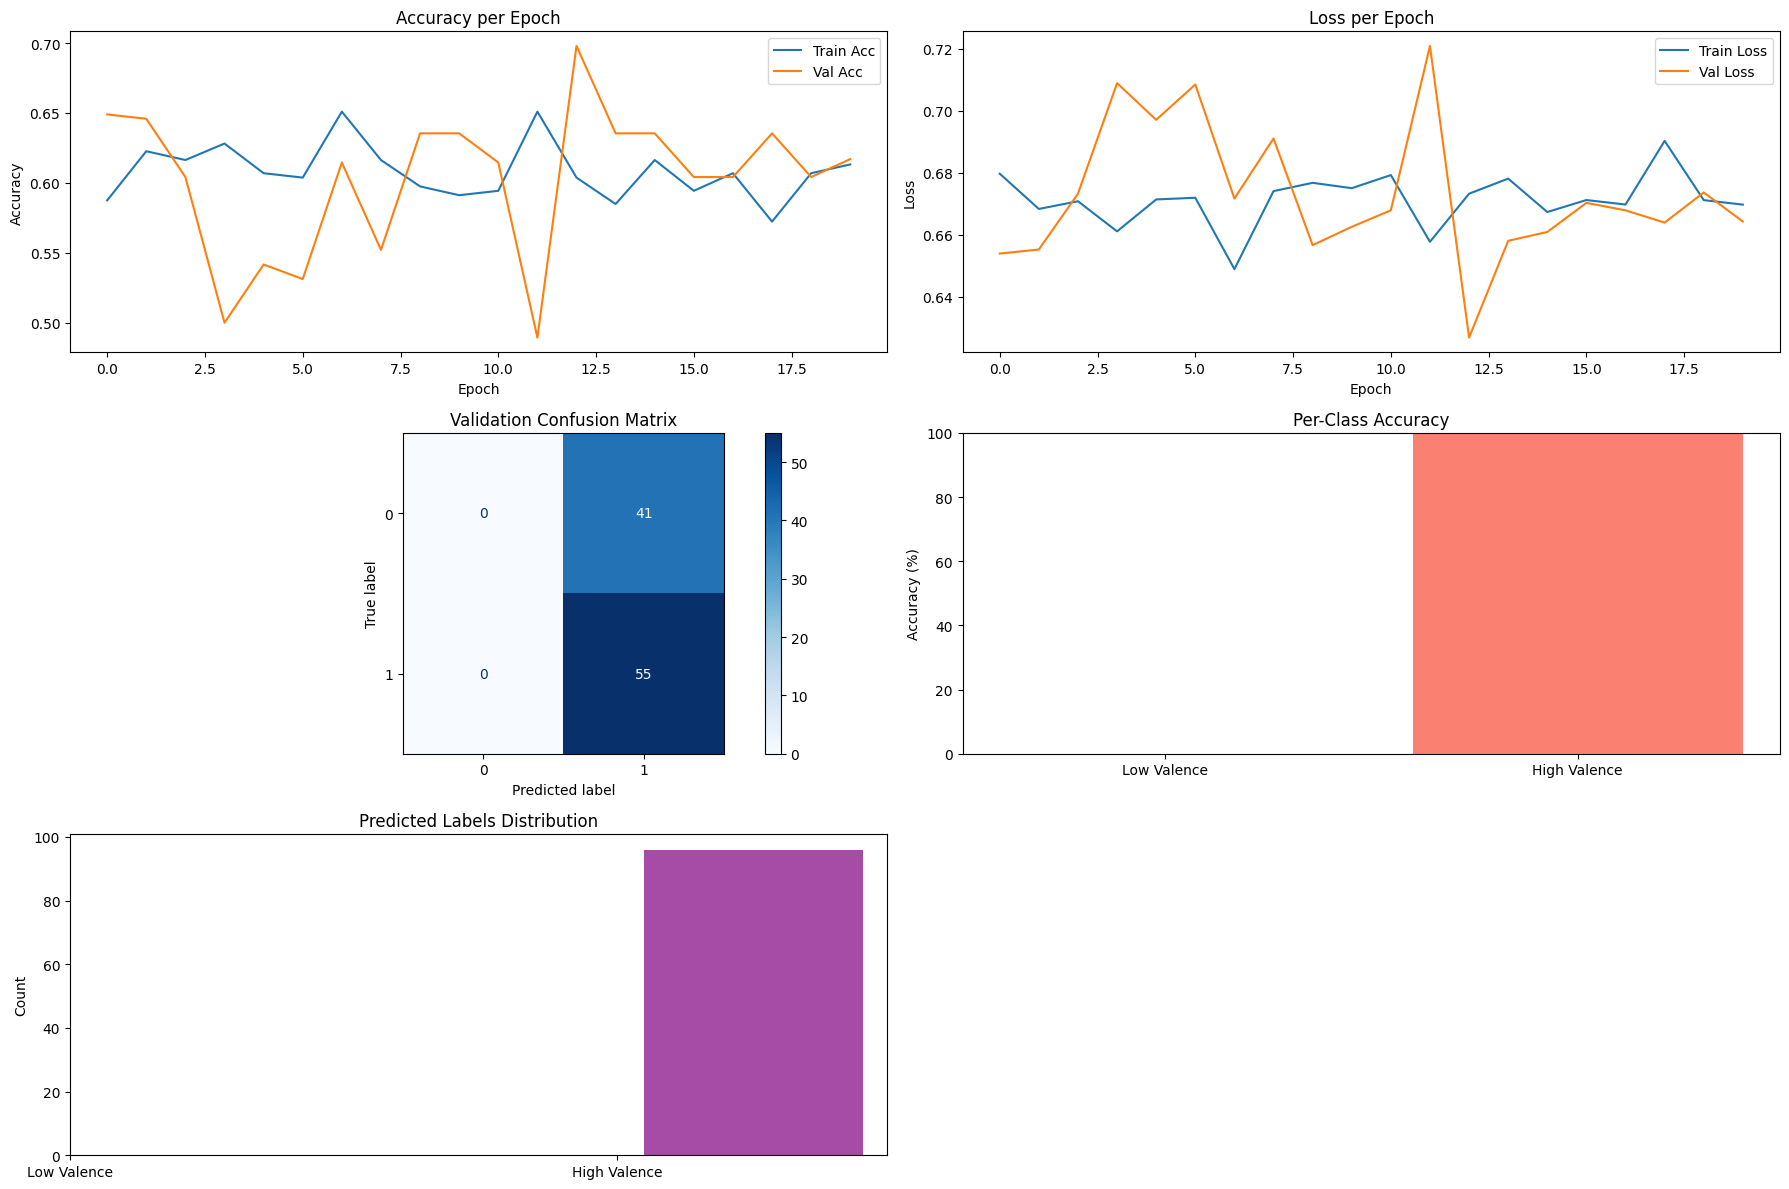

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ===========================
# Confusion Matrix
# ===========================
y_true, y_pred = [], []
for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch, verbose=0)
    preds_labels = np.argmax(preds, axis=1)
    y_pred.extend(preds_labels)
    y_true.extend(y_batch.numpy())

cm = confusion_matrix(y_true, y_pred)
class_acc = cm.diagonal() / cm.sum(axis=1)

# ===========================
# Prediction Distribution
# ===========================
plt.figure(figsize=(18,12))

# 1. Accuracy
plt.subplot(3,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 2. Loss
plt.subplot(3,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 3. Confusion Matrix
plt.subplot(3,2,3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(ax=plt.gca(), cmap=plt.cm.Blues)
plt.title("Validation Confusion Matrix")

# 4. Per-Class Accuracy
plt.subplot(3,2,4)
plt.bar([0,1], class_acc*100, color=['skyblue','salmon'])
plt.xticks([0,1], ['Low Valence', 'High Valence'])
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Accuracy')
plt.ylim(0,100)

# 5. Prediction Distribution
plt.subplot(3,2,5)
plt.hist(y_pred, bins=2, color='purple', alpha=0.7, rwidth=0.8)
plt.xticks([0,1], ['Low Valence', 'High Valence'])
plt.ylabel('Count')
plt.title('Predicted Labels Distribution')

plt.tight_layout()
plt.show()


In [11]:
# Evaluate on training set
train_loss, train_acc = model.evaluate(train_ds, verbose=0)

# Evaluate on validation/test set
val_loss, val_acc = model.evaluate(val_ds, verbose=0)

# Display results
print(f"✅ Training Accuracy: {train_acc*100:.2f}%")
print(f"✅ Validation/Test Accuracy: {val_acc*100:.2f}%")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


✅ Training Accuracy: 61.64%
✅ Validation/Test Accuracy: 70.83%
